# Customer Churn Exercise

## Notes & Assumptions

- The data is assumed to be largely clean; the checks in the **Data checks & preparation**
  section below are still run to confirm this rather than to fix widespread issues, which
  is why `data_quality_check()` is intentionally a simple/rigid helper used mainly to
  display results consistently across datasets.
- The app download dataset is expected to contain one record per customer, representing
  their first app download date. One duplicate `customer_id` was identified
  (`customer_id = 120`) with two download dates. As this was an isolated occurrence and
  the dataset definition specifies *first* download date, the earliest download date was
  retained.
- Package versions used are printed at the end of the **Imports** cell below for
  reproducibility.


## Imports & Setup

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

import sklearn
from sklearn.metrics import precision_recall_curve, roc_curve

# Record package versions for reproducibility
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")


pandas: 3.0.2
numpy: 1.26.4
scikit-learn: 1.3.0


In [2]:
# File paths (please update with appropriate file paths before running this notebook!)
acct_close_path = "data/acct-close.csv"
app_download_path = "data/app-download.csv"
app_events_path = "data/app-events.csv"
customer_profile_path = "data/customer-profile.csv"


In [3]:
# Names were slightly adjusted from the raw file names to improve readability while
# staying concise

account_closure_df = pd.read_csv(acct_close_path)
app_downloads_df = pd.read_csv(app_download_path)
app_events_df = pd.read_csv(app_events_path)
customer_profiles_df = pd.read_csv(customer_profile_path)


## Helper Functions

In [4]:
def data_quality_check(datasets, check_name):
    """
    Run a quick diagnostic check across a dictionary of {name: dataframe} pairs
    and display the result, e.g. data_quality_check(datasets, "head").

    "isna().sum()" is handled as a special case since it isn't a single valid
    attribute/method name that getattr() can resolve directly.
    """
    for name, df in datasets.items():
        print(f"{name} - {check_name}")
        print("=" * 50)

        if check_name == "isna().sum()":
            result = df.isna().sum()
        else:
            result = getattr(df, check_name)
            if callable(result):
                result = result()

        display(result)


def get_cohort_conversion(days=30):
    """
    For each app-download month cohort, compute the share of customers who
    clicked "register_ev_click" within `days` days of downloading the app.
    Only cohorts with at least `days` days of possible follow-up (relative to
    the latest event in the data) are included, to avoid understating
    still-maturing cohorts.
    """
    clicks = (
        customer_event_level_df.query("event_name == 'register_ev_click'")
        .groupby("customer_id")["timestamp"]
        .min()
        .rename("first_click")
    )

    max_date = customer_event_level_df["timestamp"].max()

    df = customer_level_df.assign(
        app_download_date=lambda x: pd.to_datetime(x["app_download_date"])
    ).merge(clicks, on="customer_id", how="left")

    df = df[df["app_download_date"] <= max_date - pd.Timedelta(days=days)].copy()

    days_to_click = (df["first_click"] - df["app_download_date"]).dt.days
    df["registered"] = days_to_click.between(0, days)

    return (
        df.groupby(df["app_download_date"].dt.to_period("M"))
        .agg(
            new_customers=("customer_id", "nunique"),
            registered=("registered", "sum"),
        )
        .assign(conversion_rate=lambda x: x["registered"] / x["new_customers"])
    )


def format_cohort_table(df, days=30):
    """Return a display-friendly copy of a cohort conversion table."""
    display_df = df.copy()
    display_df["conversion_rate"] = (
        (display_df["conversion_rate"] * 100).round(1).astype(str) + "%"
    )
    display_df.columns = [
        "New Customers",
        f"Registered Within {days} Days",
        "Conversion Rate",
    ]
    return display_df


## Data Checks & Preparation

In [5]:
# Dataset dictionary for use with data_quality_check()
datasets = {
    "Account Closure": account_closure_df,
    "App Downloads": app_downloads_df,
    "App Events": app_events_df,
    "Customer Profiles": customer_profiles_df,
}


In [6]:
data_quality_check(datasets, "head")

Account Closure - head


,customer_id,account_closed_date
0,10,2023-03-12
1,20,2022-06-27
2,25,2022-08-29
3,28,2023-01-12
4,30,2022-10-06


App Downloads - head


,customer_id,app_download_date
0,2727,2022-01-01
1,41,2022-01-01
2,1678,2022-01-01
3,2548,2022-01-01
4,2024,2022-01-02


App Events - head


,timestamp,customer_id,event_name,app_version
0,2022-01-04 23:13:29,762,submit_meter_reading,1.4
1,2022-01-06 13:08:12,1511,view_account_balance,1.4
2,2022-01-07 00:11:01,1044,view_account_balance,1.4
3,2022-01-07 02:45:06,989,view_account_balance,1.4
4,2022-01-07 04:57:26,2437,register_ev_click,1.4


Customer Profiles - head


,customer_id,tariff_type,payment_method,estimated_annual_usage_kwh
0,0,Fixed 12M,Direct Debit,2663
1,1,EV Smart,Credit/Debit Card,3878
2,2,Variable,Direct Debit,3732
3,3,EV Smart,Direct Debit,4266
4,4,Variable,Direct Debit,2867


In [7]:
data_quality_check(datasets, "isna().sum()")

Account Closure - isna().sum()


customer_id            0
account_closed_date    0
dtype: int64

App Downloads - isna().sum()


customer_id          0
app_download_date    0
dtype: int64

App Events - isna().sum()


timestamp      0
customer_id    0
event_name     0
app_version    0
dtype: int64

Customer Profiles - isna().sum()


customer_id                   0
tariff_type                   0
payment_method                0
estimated_annual_usage_kwh    0
dtype: int64

In [8]:
data_quality_check(datasets, "dtypes")

Account Closure - dtypes


customer_id            int64
account_closed_date      str
dtype: object

App Downloads - dtypes


customer_id          int64
app_download_date      str
dtype: object

App Events - dtypes


timestamp          str
customer_id      int64
event_name         str
app_version    float64
dtype: object

Customer Profiles - dtypes


customer_id                   int64
tariff_type                     str
payment_method                  str
estimated_annual_usage_kwh    int64
dtype: object

In [9]:
data_quality_check(datasets, "shape")

Account Closure - shape


(366, 2)

App Downloads - shape


(3001, 2)

App Events - shape


(10366, 4)

Customer Profiles - shape


(3000, 4)

In [10]:
# Check for duplicate customer IDs in the datasets that should be one-row-per-customer

print(f"Customer profile customer_id duplicates: {customer_profiles_df['customer_id'].duplicated().sum()}")
print(f"Account closure customer_id duplicates: {account_closure_df['customer_id'].duplicated().sum()}")
print(f"App downloads customer_id duplicates: {app_downloads_df['customer_id'].duplicated().sum()}")


Customer profile customer_id duplicates: 0
Account closure customer_id duplicates: 0
App downloads customer_id duplicates: 1


In [11]:
# App downloads has a duplicate value, so it is investigated further
# (see Notes & Assumptions above for the resolution)

print("Duplicate rows in App Downloads:")
display(app_downloads_df[app_downloads_df["customer_id"].duplicated(keep=False)].sort_values("customer_id"))

print("Affected customer's app usage timeline:")
display(app_events_df[app_events_df["customer_id"] == 120])

# Remove the duplicate by keeping the earliest download date
app_downloads_clean_df = (
    app_downloads_df
    .sort_values("app_download_date")
    .drop_duplicates(subset="customer_id", keep="first")
    .copy()
)

# Recheck for duplicates
print(f"App downloads customer_id duplicates after cleaning: {app_downloads_clean_df['customer_id'].duplicated().sum()}")


Duplicate rows in App Downloads:


,customer_id,app_download_date
191,120,2022-01-13
2462,120,2022-07-20


Affected customer's app usage timeline:


,timestamp,customer_id,event_name,app_version
33,2022-01-17 11:06:00,120,register_ev_click,1.4
51,2022-01-23 04:36:27,120,submit_meter_reading,1.4
828,2022-04-02 08:21:46,120,view_account_balance,1.4
1275,2022-04-29 15:09:10,120,submit_meter_reading,1.4
2639,2022-06-30 18:01:21,120,submit_meter_reading,1.4
5505,2022-10-21 02:43:23,120,view_account_balance,1.5
7333,2023-01-01 20:12:14,120,view_account_balance,1.5
9612,2023-03-30 09:21:36,120,submit_meter_reading,1.5
10236,2023-04-22 16:54:26,120,submit_meter_reading,1.5


App downloads customer_id duplicates after cleaning: 0


In [12]:
# Create clean copies of the remaining dataframes

account_closure_clean_df = account_closure_df.copy()
app_events_clean_df = app_events_df.copy()

# No further cleaning is needed for customer profiles, but a "_clean" copy is
# still made for naming consistency with the other dataframes
customer_profiles_clean_df = customer_profiles_df.copy()

# Convert date columns to proper datetime dtype
account_closure_clean_df["account_closed_date"] = pd.to_datetime(
    account_closure_df["account_closed_date"]
)
app_downloads_clean_df["app_download_date"] = pd.to_datetime(
    app_downloads_df["app_download_date"]
)
app_events_clean_df["timestamp"] = pd.to_datetime(
    app_events_df["timestamp"]
)


In [13]:
# Create merged dataframes for further analysis

# One row per customer
customer_level_df = (
    customer_profiles_clean_df
    .merge(app_downloads_clean_df, on="customer_id", how="left")
    .merge(account_closure_clean_df, on="customer_id", how="left")
)

# One row per event
customer_event_level_df = (
    app_events_clean_df
    .merge(customer_profiles_clean_df, on="customer_id", how="left")
    .merge(app_downloads_clean_df, on="customer_id", how="left")
    .merge(account_closure_clean_df, on="customer_id", how="left")
)


In [14]:
# Check row counts before/after each merge (should be unchanged, as both are left joins)

print("Customer-level merge:")
print(f"  Rows before: {len(customer_profiles_clean_df)}")
print(f"  Rows after:  {len(customer_level_df)}")
print(f"  Rows dropped: {len(customer_profiles_clean_df) - len(customer_level_df)}")

print("\nEvent-level merge:")
print(f"  Rows before: {len(app_events_clean_df)}")
print(f"  Rows after:  {len(customer_event_level_df)}")
print(f"  Rows dropped: {len(app_events_clean_df) - len(customer_event_level_df)}")


Customer-level merge:
  Rows before: 3000
  Rows after:  3000
  Rows dropped: 0

Event-level merge:
  Rows before: 10366
  Rows after:  10366
  Rows dropped: 0


## Part 1
## Exploratory Data Analysis

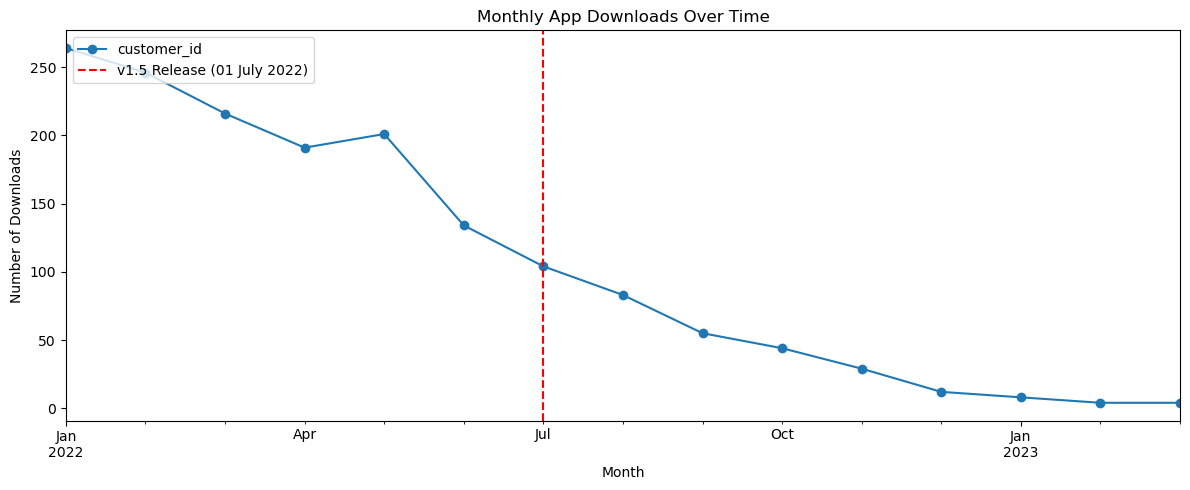

In [15]:
# Line Graph of Monthly App Downloads Over Time

monthly_downloads = (
    customer_event_level_df
    .groupby(customer_event_level_df["app_download_date"].dt.to_period("M"))
    ["customer_id"]
    .nunique()
)

ax = monthly_downloads.plot(
    kind="line",
    figsize=(12, 5),
    marker="o",
    title="Monthly App Downloads Over Time",
    xlabel="Month",
    ylabel="Number of Downloads",
)

plt.axvline(
    x="2022-07",
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="v1.5 Release (01 July 2022)",
)

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


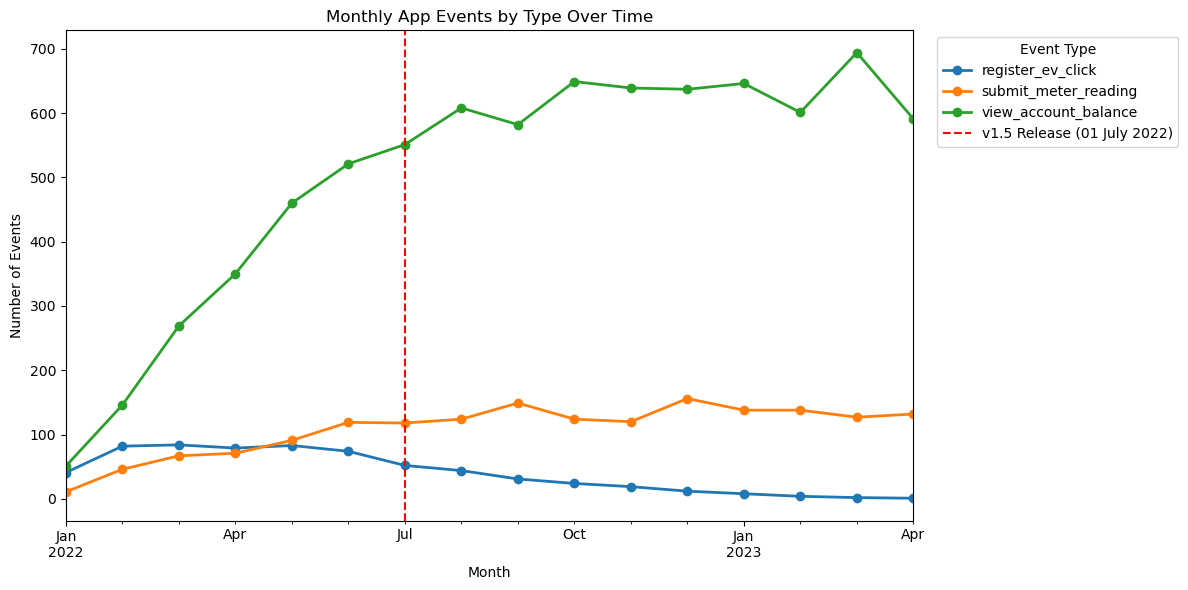

In [16]:
#Monthly counts for each event type
monthly_events_by_type = (
    customer_event_level_df
    .groupby([customer_event_level_df["timestamp"].dt.to_period("M"), "event_name"])
    .size()
    .unstack(fill_value=0)
)

ax = monthly_events_by_type.plot(
    kind="line",
    figsize=(12, 6),
    marker="o",
    linewidth=2,
    title="Monthly App Events by Type Over Time",
    xlabel="Month",
    ylabel="Number of Events",
)

plt.axvline(
    x="2022-07",
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="v1.5 Release (01 July 2022)",
)

plt.legend(title="Event Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


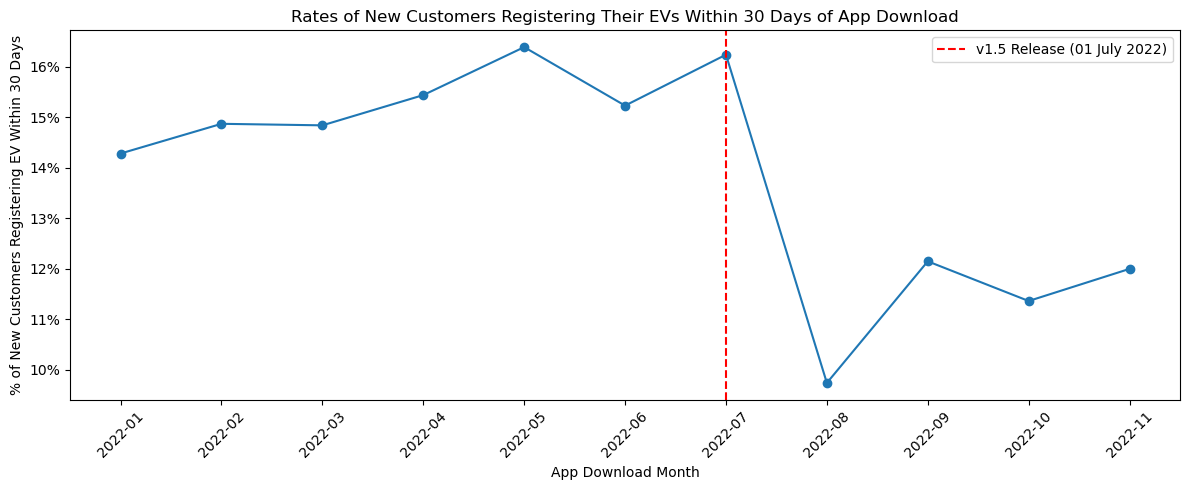

In [17]:
def plot_cohort_conversion(cohort_df, days, end_period="2022-11"):
    """Plot a cohort conversion-rate table produced by get_cohort_conversion()."""
    plot_df = cohort_df.loc[:end_period]

    fig, ax = plt.subplots(figsize=(12, 5))
    x_labels = plot_df.index.astype(str)

    ax.plot(x_labels, plot_df["conversion_rate"], marker="o", color="#1f77b4")
    ax.set(
        title=f"Rates of New Customers Registering Their EVs Within {days} Days of App Download",
        xlabel="App Download Month",
        ylabel=f"% of New Customers Registering EV Within {days} Days",
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.xticks(rotation=45)

    if "2022-07" in x_labels:
        idx = x_labels.get_loc("2022-07")
        ax.axvline(
            x=idx,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label="v1.5 Release (01 July 2022)",
        )

    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


cohort_30 = get_cohort_conversion(days=30)
plot_cohort_conversion(cohort_30, days=30)


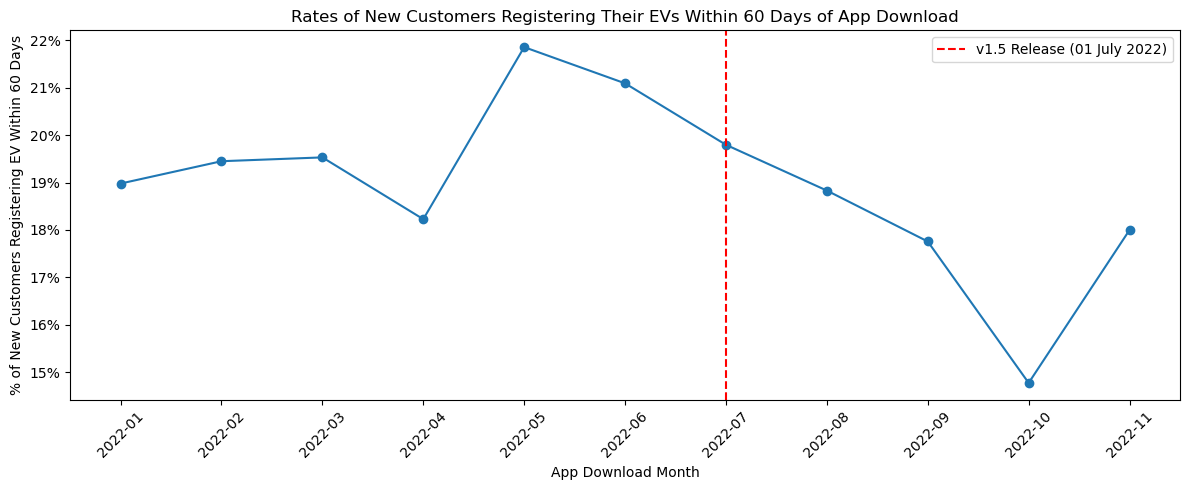

In [18]:
cohort_60 = get_cohort_conversion(days=60)
plot_cohort_conversion(cohort_60, days=60)


# Part 2

## Prepare Modelling Dataset

### Window and Time Frame Exploration

In [19]:
# Explore candidate cutoff/window combinations to find one that yields enough
# churned customers to model on, for both the training and validation splits

closures = account_closure_df.copy()
closures["account_closed_date"] = pd.to_datetime(closures["account_closed_date"])

data_start = pd.Timestamp("2022-01-01")
data_end = pd.Timestamp("2023-04-19")

results = []

for window in [2, 3, 4, 6]:
    for split, cutoff in {
        "train": data_end - pd.DateOffset(months=2 * window),
        "validation": data_end - pd.DateOffset(months=window),
    }.items():

        window_end = cutoff + pd.DateOffset(months=window)

        churned = (
            (closures["account_closed_date"] > cutoff)
            & (closures["account_closed_date"] <= window_end)
        ).sum()

        results.append({
            "split": split,
            "window_months": window,
            "cutoff": cutoff.date(),
            "feature_days": (cutoff - data_start).days,
            "churned": churned,
        })

results_df = pd.DataFrame(results)
results_df


,split,window_months,cutoff,feature_days,churned
0,train,2,2022-12-19,352,24
1,validation,2,2023-02-19,414,18
2,train,3,2022-10-19,291,48
3,validation,3,2023-01-19,383,27
4,train,4,2022-08-19,230,95
5,validation,4,2022-12-19,352,42
6,train,6,2022-04-19,108,219
7,validation,6,2022-10-19,291,75


Based on the exploration above, the following cutoff dates and window lengths were
selected for the training and validation splits. These constants are reused for every
step below so the training and validation datasets stay consistent.

In [20]:
# Chosen cutoff/window settings (used consistently throughout the rest of this section)
TRAIN_CUTOFF = "2022-07-19"
TRAIN_WINDOW_MONTHS = 4

VALID_CUTOFF = "2022-11-19"
VALID_WINDOW_MONTHS = 5

# Confirm the number of customers churned in the selected training window
T = pd.Timestamp(TRAIN_CUTOFF)
window_end = T + pd.DateOffset(months=TRAIN_WINDOW_MONTHS)

churned = (
    (closures["account_closed_date"] > T)
    & (closures["account_closed_date"] <= window_end)
).sum()

print(f"Cutoff: {T.date()}")
print(f"Window: {TRAIN_WINDOW_MONTHS} months")
print(f"Churned: {churned}")


Cutoff: 2022-07-19
Window: 4 months
Churned: 125


### Build Training & Validation Datasets

In [21]:
def build_model_dataset(customer_level_df, app_events_df, cutoff_date, window_months):
    """
    Build a one-row-per-customer modelling dataset as of `cutoff_date`, with a
    `churned` target computed over the following `window_months`.

    Only customers who had downloaded the app by the cutoff and had not
    already closed their account are included, and only events observed
    before the cutoff are used, to avoid leaking future information into the
    features.
    """
    T = pd.Timestamp(cutoff_date)
    window_end = T + pd.DateOffset(months=window_months)

    # Ensure datetime columns
    customer_level_df = customer_level_df.copy()
    customer_level_df["app_download_date"] = pd.to_datetime(customer_level_df["app_download_date"])
    customer_level_df["account_closed_date"] = pd.to_datetime(customer_level_df["account_closed_date"])
    app_events_df = app_events_df.copy()
    app_events_df["timestamp"] = pd.to_datetime(app_events_df["timestamp"])

    # 1. Keep customers eligible for prediction
    eligible_df = customer_level_df[
        (customer_level_df["app_download_date"] <= T) &
        (
            customer_level_df["account_closed_date"].isna() |
            (customer_level_df["account_closed_date"] > T)
        )
    ].copy()

    # 2. Keep only events observed before the cutoff
    events_before_T = app_events_df[app_events_df["timestamp"] <= T].copy()

    # 3. Aggregate events to one row per customer
    event_summary = (
        events_before_T
        .groupby("customer_id")
        .agg(
            total_events=("event_name", "count"),
            first_event=("timestamp", "min"),
            last_event=("timestamp", "max"),
            unique_event_types=("event_name", "nunique"),
        )
        .reset_index()
    )

    event_counts = (
        events_before_T
        .pivot_table(index="customer_id", columns="event_name", aggfunc="size", fill_value=0)
        .reset_index()
    )

    event_summary = event_summary.merge(event_counts, on="customer_id", how="left")

    # 4. Merge onto customer data
    model_df = eligible_df.merge(event_summary, on="customer_id", how="left")

    # Customers with no events: fill missing numeric event columns with 0.
    # first_event/last_event are intentionally left as NaN here (rather than
    # filled with 0, which would silently become the epoch date 1970-01-01)
    # and are instead handled explicitly in engineer_features() below.
    numeric_event_cols = [
        col for col in event_summary.columns
        if col not in ["customer_id", "first_event", "last_event"]
    ]
    model_df[numeric_event_cols] = model_df[numeric_event_cols].fillna(0)

    # 5. Create churn target
    model_df["churned"] = (
        (model_df["account_closed_date"] > T) &
        (model_df["account_closed_date"] <= window_end)
    ).astype(int)

    return model_df


def engineer_features(model_df, cutoff_date):
    """Add tenure/recency/engagement features to a dataset from build_model_dataset()."""
    model_df = model_df.copy()
    T = pd.Timestamp(cutoff_date)

    model_df["app_download_date"] = pd.to_datetime(model_df["app_download_date"])
    model_df["first_event"] = pd.to_datetime(model_df["first_event"])
    model_df["last_event"] = pd.to_datetime(model_df["last_event"])

    # 1. Customer tenure
    model_df["tenure_days"] = (T - model_df["app_download_date"]).dt.days

    # 2. Recency of engagement
    model_df["days_since_last_event"] = (T - model_df["last_event"]).dt.days

    # 3. Time taken to engage with the app after download
    model_df["days_to_first_event"] = (
        model_df["first_event"] - model_df["app_download_date"]
    ).dt.days

    # 4. Customers with no events: fall back to tenure_days
    model_df["has_app_activity"] = (model_df["total_events"] > 0).astype(int)
    model_df["days_since_last_event"] = model_df["days_since_last_event"].fillna(model_df["tenure_days"])
    model_df["days_to_first_event"] = model_df["days_to_first_event"].fillna(model_df["tenure_days"])

    # 5. EV engagement feature
    model_df["has_registered_ev"] = (model_df["register_ev_click"] > 0).astype(int)

    return model_df


DROP_COLS = [
    "customer_id",
    "account_closed_date",
    "register_ev_click",
    "app_download_date",
    "first_event",
    "last_event",
]


def prepare_split(customer_level_df, app_events_df, cutoff_date, window_months, drop_cols=DROP_COLS):
    """Build a fully feature-engineered, model-ready dataset for one cutoff/window split."""
    model_df = build_model_dataset(customer_level_df, app_events_df, cutoff_date, window_months)
    model_df = engineer_features(model_df, cutoff_date)
    return model_df.drop(columns=drop_cols)


In [22]:
model_df = prepare_split(
    customer_level_df, app_events_clean_df,
    cutoff_date=TRAIN_CUTOFF, window_months=TRAIN_WINDOW_MONTHS,
)

print(model_df.shape)
model_df["churned"].value_counts()


(2273, 13)


churned
0    2168
1     105
Name: count, dtype: int64

In [23]:
model_validation_df = prepare_split(
    customer_level_df, app_events_clean_df,
    cutoff_date=VALID_CUTOFF, window_months=VALID_WINDOW_MONTHS,
)

print(model_validation_df.shape)
model_validation_df["churned"].value_counts()


(2598, 13)


churned
0    2550
1      48
Name: count, dtype: int64

### Training Model

In [24]:
# Prepare training and validation data
X_train = model_df.drop(columns="churned")
y_train = model_df["churned"]

X_validation = model_validation_df.drop(columns="churned")
y_validation = model_validation_df["churned"]

categorical_cols = ["tariff_type", "payment_method"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ]
)

# Logistic regression pipeline
log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

# Hyperparameter tuning
param_grid = {"model__C": [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best parameters:")
print(grid_search.best_params_)

# Validation evaluation
y_pred = best_model.predict(X_validation)
y_prob = best_model.predict_proba(X_validation)[:, 1]

print("\nAccuracy:")
print(accuracy_score(y_validation, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_validation, y_pred))

print("\nClassification Report:")
print(classification_report(y_validation, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_validation, y_prob))


Best parameters:
{'model__C': 0.01}

Accuracy:
0.8822170900692841

Confusion Matrix:
[[2270  280]
 [  26   22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      2550
           1       0.07      0.46      0.13        48

    accuracy                           0.88      2598
   macro avg       0.53      0.67      0.53      2598
weighted avg       0.97      0.88      0.92      2598


ROC-AUC:
0.7653513071895425


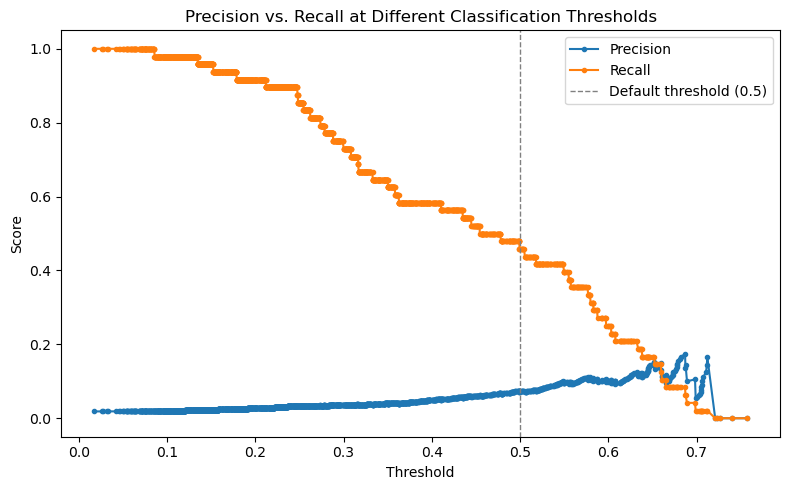

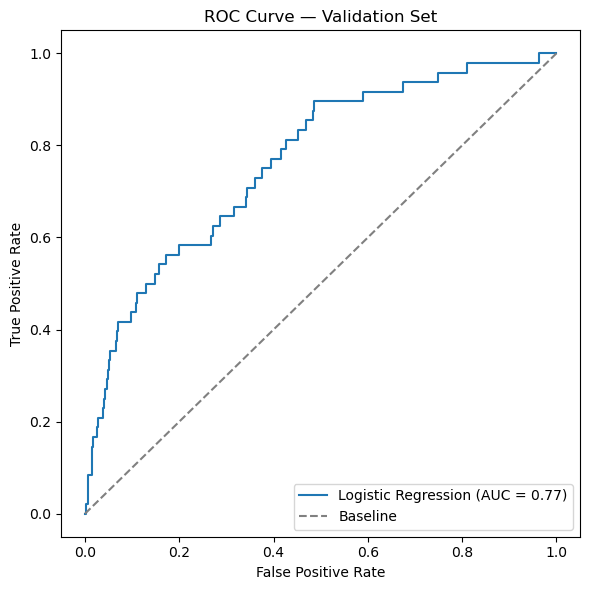

In [25]:
# Precision-Recall vs. Threshold 
precision, recall, pr_thresholds = precision_recall_curve(y_validation, y_prob)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pr_thresholds, precision[:-1], label="Precision", marker=".")
ax.plot(pr_thresholds, recall[:-1], label="Recall", marker=".")
ax.axvline(x=0.5, color="grey", linestyle="--", linewidth=1, label="Default threshold (0.5)")
ax.set(
    title="Precision vs. Recall at Different Classification Thresholds",
    xlabel="Threshold",
    ylabel="Score",
)
ax.legend()
plt.tight_layout()
plt.show()

# --- ROC Curve ---
fpr, tpr, roc_thresholds = roc_curve(y_validation, y_prob)
auc_score = roc_auc_score(y_validation, y_prob)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.2f})", color="#1f77b4")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Baseline")
ax.set(
    title="ROC Curve — Validation Set",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Appendix

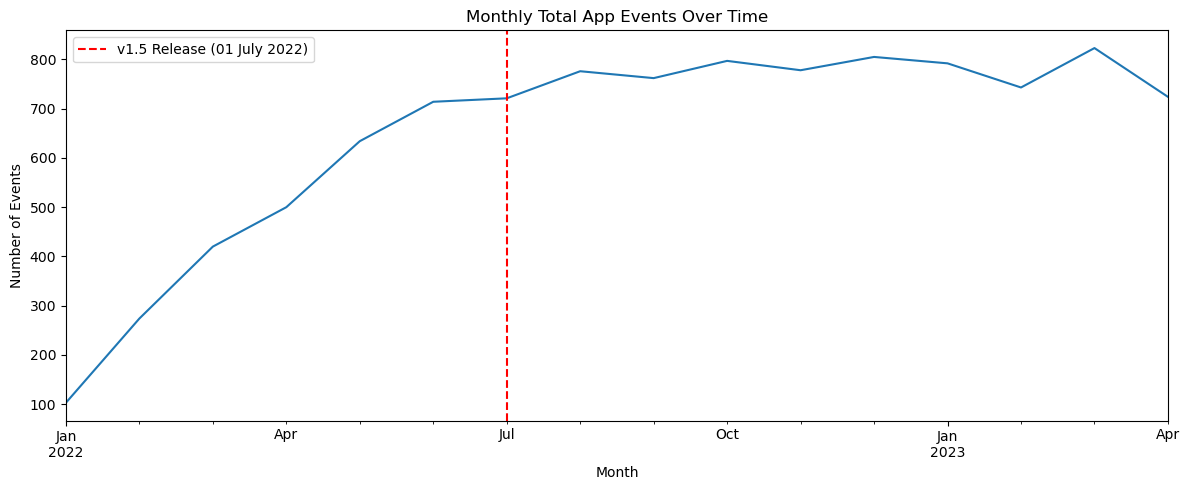

In [26]:
total_events = (
    customer_event_level_df
    .groupby(customer_event_level_df["timestamp"].dt.to_period("M"))
    .size()
)

ax = total_events.plot(
    kind="line",
    figsize=(12, 5),
    title="Monthly Total App Events Over Time",
    xlabel="Month",
    ylabel="Number of Events",
)

plt.axvline(
    x="2022-07",
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="v1.5 Release (01 July 2022)",
)

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


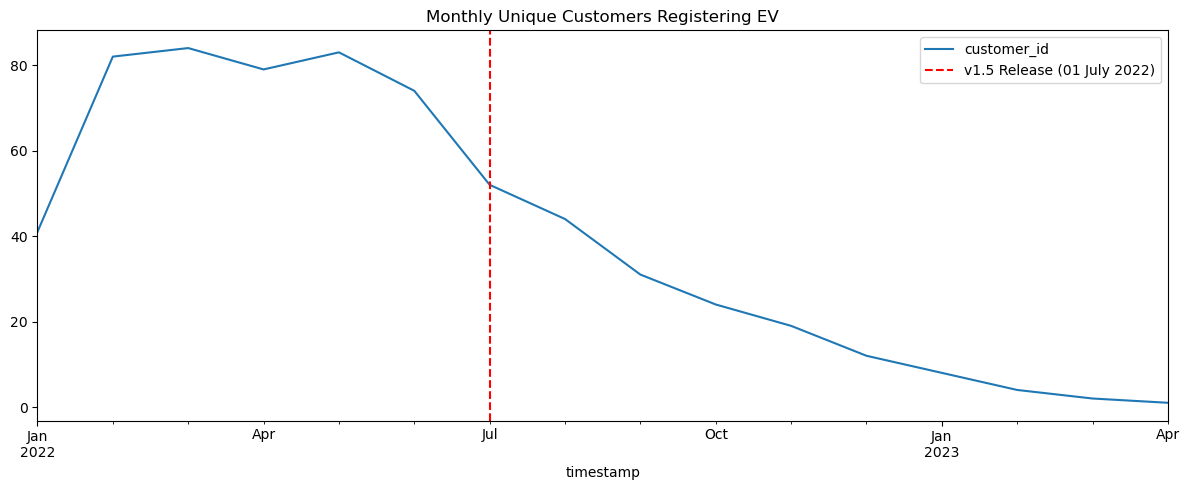

In [27]:
monthly_register_users = (
    customer_event_level_df[customer_event_level_df["event_name"] == "register_ev_click"]
    .groupby(customer_event_level_df["timestamp"].dt.to_period("M"))
    ["customer_id"]
    .nunique()
)

ax = monthly_register_users.plot(
    kind="line",
    figsize=(12, 5),
    title="Monthly Unique Customers Registering EV",
)

plt.axvline(
    x="2022-07",
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="v1.5 Release (01 July 2022)",
)

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [28]:
print(format_cohort_table(cohort_30, days=30))

                   New Customers  Registered Within 30 Days Conversion Rate
app_download_date                                                          
2022-01                      490                         70           14.3%
2022-02                      437                         65           14.9%
2022-03                      384                         57           14.8%
2022-04                      395                         61           15.4%
2022-05                      366                         60           16.4%
2022-06                      256                         39           15.2%
2022-07                      197                         32           16.2%
2022-08                      154                         15            9.7%
2022-09                      107                         13           12.1%
2022-10                       88                         10           11.4%
2022-11                       50                          6           12.0%
2022-12     

In [29]:
print(format_cohort_table(cohort_60, days=60))

                   New Customers  Registered Within 60 Days Conversion Rate
app_download_date                                                          
2022-01                      490                         93           19.0%
2022-02                      437                         85           19.5%
2022-03                      384                         75           19.5%
2022-04                      395                         72           18.2%
2022-05                      366                         80           21.9%
2022-06                      256                         54           21.1%
2022-07                      197                         39           19.8%
2022-08                      154                         29           18.8%
2022-09                      107                         19           17.8%
2022-10                       88                         13           14.8%
2022-11                       50                          9           18.0%
2022-12     